In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)



In [3]:


#Basic Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
    ])

#Download Dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

#Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)



In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class InitialCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):

        x = torch.sigmoid(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv4(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)

        return x


In [5]:

# 6. Initialize Network
model = InitialCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


In [6]:

# 7. Training Function
def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    train_f1 = f1_score(all_labels, all_preds, average="macro")

    avg_loss = running_loss / len(loader)
    return avg_loss, accuracy, train_f1, gradient_norms


In [7]:

# 8. Testing Function
def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    test_f1 = f1_score(all_labels, all_preds, average="macro")

    avg_loss = running_loss / len(loader)
    return avg_loss, accuracy, test_f1


In [8]:
num_epochs = 15

train_losses = []
test_losses = []

train_accs = []
test_accs = []
train_f1s = []
test_f1s = []
all_epoch_gradient_norms = []

for epoch in range(num_epochs):

    # 1. Run training and testing
    train_loss, train_acc, train_f1, grad_norms = train(model, train_loader)
    test_loss, test_acc, test_f1 = test(model, test_loader)

    # 2. Storage
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    train_f1s.append(train_f1)
    test_f1s.append(test_f1)
    
    # 3. Process Gradients (Fixed variable name here)
    epoch_grad_averages = {}
    for layer_name, batch_norms in grad_norms.items():
        epoch_grad_averages[layer_name] = sum(batch_norms) / len(batch_norms)
    
    all_epoch_gradient_norms.append(epoch_grad_averages)
    
    # 4. MONITORING
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}% | Test Accuracy: {test_acc:.2f}%")
    print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f}")

    # --- ADDED: Print Gradient Magnitudes ---
    print("Average Gradient Magnitudes:")
    for layer, magnitude in epoch_grad_averages.items():
        # Using :.6f because these numbers might be very small!

        print(f"  {layer}: {magnitude:.6f}")


    print("-" * 40)

Epoch 1/15
Train Loss: 2.1461 | Test Loss: 1.9457
Train Accuracy: 18.56% | Test Accuracy: 27.00%
Train F1: 0.1753 | Test F1: 0.2178
Average Gradient Magnitudes:
  conv1.weight: 0.018566
  conv1.bias: 0.016668
  conv2.weight: 0.040352
  conv2.bias: 0.005227
  conv3.weight: 0.008940
  conv3.bias: 0.008499
  conv4.weight: 0.056824
  conv4.bias: 0.003642
  fc1.weight: 0.052657
  fc1.bias: 0.012005
  fc2.weight: 0.709237
  fc2.bias: 0.092316
----------------------------------------
Epoch 2/15
Train Loss: 1.8759 | Test Loss: 1.7386
Train Accuracy: 31.19% | Test Accuracy: 36.99%
Train F1: 0.2927 | Test F1: 0.3438
Average Gradient Magnitudes:
  conv1.weight: 0.051917
  conv1.bias: 0.051910
  conv2.weight: 0.254079
  conv2.bias: 0.027084
  conv3.weight: 0.066066
  conv3.bias: 0.021672
  conv4.weight: 0.113456
  conv4.bias: 0.007110
  fc1.weight: 0.091642
  fc1.bias: 0.011165
  fc2.weight: 0.663273
  fc2.bias: 0.089808
----------------------------------------
Epoch 3/15
Train Loss: 1.6964 | Test

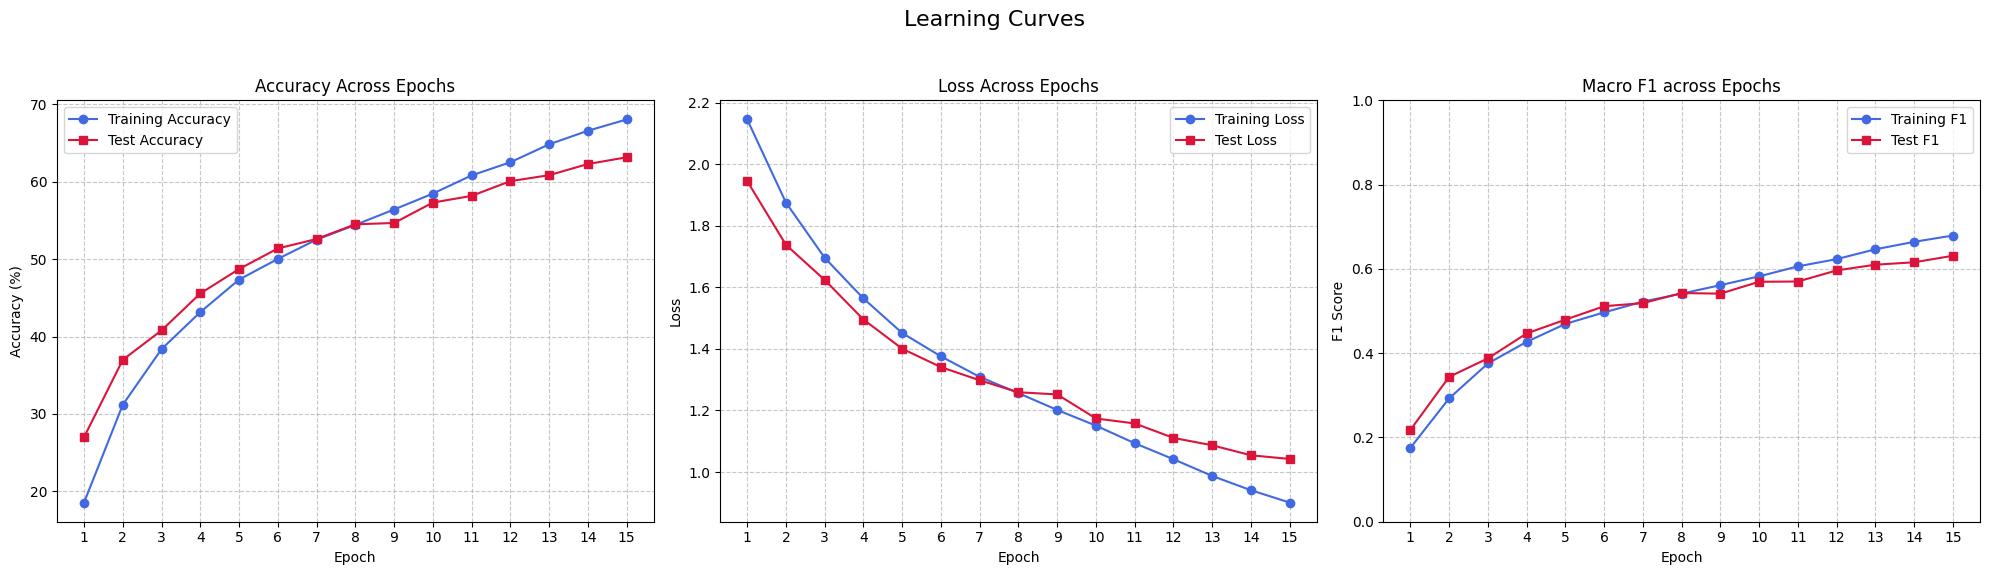

In [9]:
import matplotlib.pyplot as plt

# Define the epoch range (1 to 15)
epochs = range(1, num_epochs + 1)

# Create the main figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Learning Curves', fontsize=16)

# --- Plot 1: Accuracy ---
ax1.plot(epochs, train_accs, marker='o', label='Training Accuracy', color='royalblue')
ax1.plot(epochs, test_accs, marker='s', label='Test Accuracy', color='crimson')
ax1.set_title('Accuracy Across Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks(epochs) # Ensure axis shows every epoch from 1 to 15
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Loss ---
ax2.plot(epochs, train_losses, marker='o', label='Training Loss', color='royalblue')
ax2.plot(epochs, test_losses, marker='s', label='Test Loss', color='crimson')
ax2.set_title('Loss Across Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_xticks(epochs) # Ensure axis shows every epoch from 1 to 15
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# --- Plot 3: F1 Score ---
ax3.plot(epochs, train_f1s, marker='o', label='Training F1', color='royalblue')
ax3.plot(epochs, test_f1s, marker='s', label='Test F1', color='crimson')
ax3.set_title('Macro F1 across Epochs')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('F1 Score')
ax3.set_xticks(epochs)
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

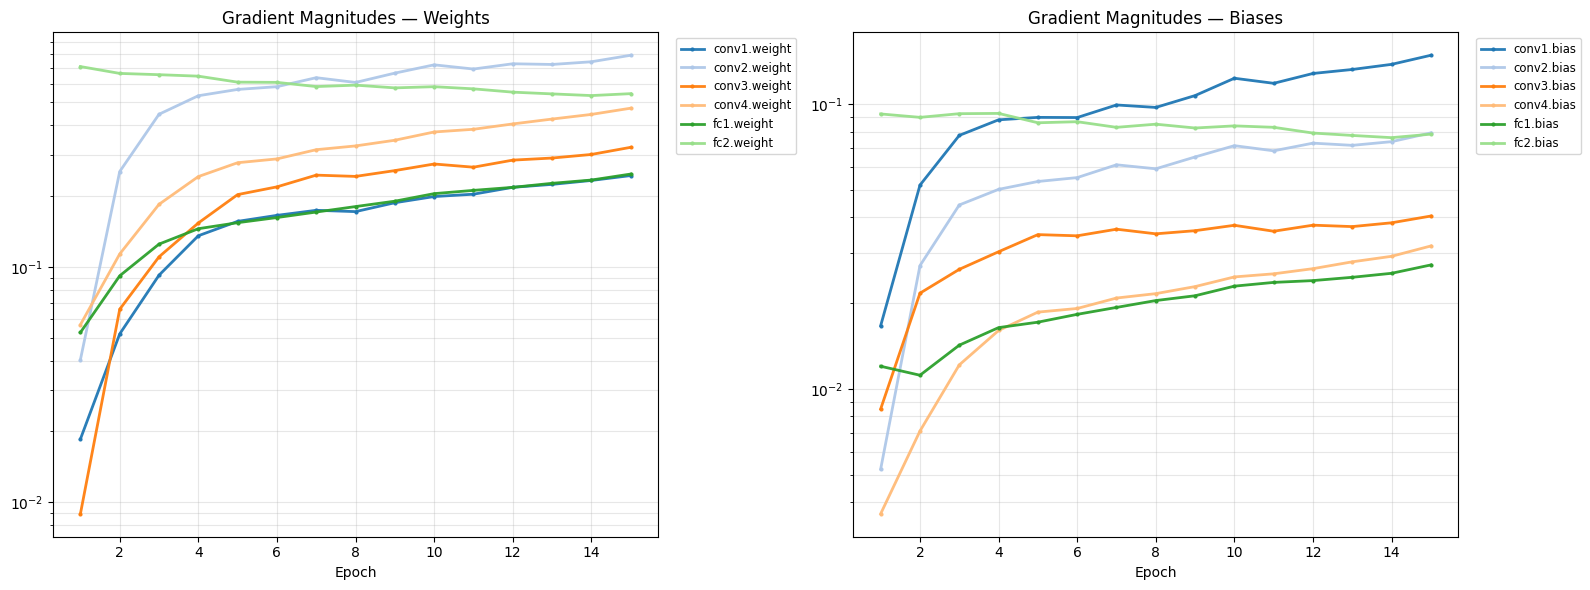

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Define the epoch range
epochs = range(1, num_epochs + 1)

# Collect parameter names and split into weights vs biases
all_names = list(all_epoch_gradient_norms[0].keys())
weight_names = [n for n in all_names if 'bias' not in n.lower()]
bias_names = [n for n in all_names if 'bias' in n.lower()]

# Create side-by-side subplots: weights | biases
fig, (ax_w, ax_b) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
cmap = plt.get_cmap('tab20')

def plot_group(ax, names, title):
    colors = [cmap(i % cmap.N) for i in range(len(names))]
    for idx, name in enumerate(names):
        history = [epoch_data[name] for epoch_data in all_epoch_gradient_norms]
        ax.plot(epochs, history, label=name, marker='.', color=colors[idx], linewidth=2, markersize=4, alpha=0.95)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_yscale('log')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=10))
    ax.grid(True, which='both', ls='-', alpha=0.3)

# Plot weights and biases separately
plot_group(ax_w, weight_names, 'Gradient Magnitudes — Weights')
plot_group(ax_b, bias_names, 'Gradient Magnitudes — Biases')

# Place legends outside each subplot
ax_w.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
ax_b.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()